In [26]:
import source.schedulers as schedulers
import source.neural_network as NN
import source.activation_functions as activation_functions
import source.cost_functions as cost_functions
import source.utils as utils
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [27]:
# Custom imports
from source.mnist_preprocessing import ITERATIONS, MNIST_RANDOM_STATE, TORCH_SEED
from source.mnist_preprocessing import HIDDEN_LAYERS, BATCH_SIZE, ETA_VALUES, LAMBDA_VALUES
from source.mnist_preprocessing import MOMENTUM,NP_RANDOM_SEED

In [28]:
MNIST_RANDOM_STATE = 42
TEST_SPLIT = 0.2
# Download MNIST dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Extract data (features) and target (labels)
X = mnist.data
y = mnist.target

# Scaling pixel values
X = X / 255.0

enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y.reshape(-1,1))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=TEST_SPLIT, random_state=MNIST_RANDOM_STATE)




In [29]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(56000, 10))

In [30]:
number_batch = int(np.floor(X_test.shape[0]/BATCH_SIZE))

In [31]:
ACTIVATION_FUNCTION = activation_functions.RELU
ACTIVATION_FUNCTION_DERIVATIVE = activation_functions.RELU_derivative
ACTIVATION_FUNCTION_OUTPUT = activation_functions.softmax
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = None
cost_fn = cost_functions.class_multiclass_cross_entropy(l1=0, l2=0)

activations, activations_derivative, _dim = utils.create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, 
                                                                        ACTIVATION_FUNCTION_OUTPUT,ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE,
                                                                        HIDDEN_LAYERS, y_train, X_train)


In [32]:

# Define model as input to loop to ensure new model each iteration
def model_classify_fn():
    return NN.NN(_dim, activations, activations_derivative, cost_fn, NP_RANDOM_SEED)


classify_results = utils.neural_network_loop(model_classify_fn,
                                              ETA_VALUES, LAMBDA_VALUES,
                                                'ADAM', 
                                                ITERATIONS, 
                                                X_train, y_train, 
                                                X_test, y_test,
                                                batch_val=number_batch,
                                                rho=0.0,
                                                rho2=0.0)

Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: True
L1 and L2 term
0
0
Using scheduler: A

In [40]:
def accuracy(prediction,target):
    assert prediction.size == target.size
    return np.average((target == prediction))

accuracy_list = []

for prediction in classify_results.Predictions:
    accuracy_list.append(accuracy(prediction,y_test))

applied_df = classify_results.assign(Accuracy=accuracy_list)

In [41]:
applied_df

,Learning Rate,Lambda,Iterations,Elapsed Time (s),Training Errors,Validation Errors,MSE train,MSE test,Predictions,Accuracy
0,0.1000,0.010000,50,39.23,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
1,0.1000,0.005995,50,40.86,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
2,0.1000,0.003594,50,43.97,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
3,0.1000,0.002154,50,45.35,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
4,0.1000,0.001292,50,44.35,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
5,0.1000,0.000774,50,45.31,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
6,0.1000,0.000464,50,43.41,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
7,0.1000,0.000278,50,44.49,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
8,0.1000,0.000167,50,45.85,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007
9,0.1000,0.000100,50,44.63,"[2.302587924513299, 2.302570067370442, 2.30257...","[2.3025964190710884, 2.30252499049966, 2.30252...",2.302570,2.302525,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, ...",0.900007


In [34]:
import source.plotting as plotting

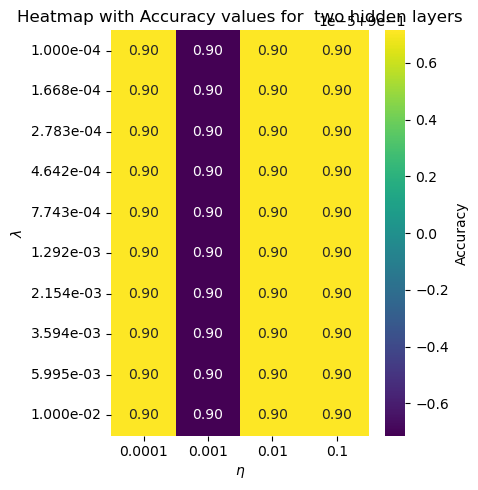

In [46]:

task = 'part_f'
hidden_str = 'hidden_32_16'
algo = 'ownNN'
plot_type = 'heatmap'

filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ITERATIONS}-batch{number_batch}-{algo}'

plotting.plot_heatmap(applied_df, 'Accuracy',
              y_axis_scientific=True, 
              title='Heatmap with Accuracy values for  two hidden layers', 
             filename = 'plain-sgd_' + filename_values)

In [ ]:
ETA= 0.5    # eta 0.5 in runge_preprocessing ETAs?

print(f'Dimensions of input, hidden, and output layer:\n{_dim}')
optimizer_ADAM = schedulers.ADAM(eta=ETA_VALUES[2], rho=0, rho2=0) 
optimizer_momentum = schedulers.momentum(eta=ETA, momentum=MOMENTUM)
optimizer_RMSprop = schedulers.RMSprop(eta=ETA,rho=0)

NN_classify = NN.NN(dims = _dim, 
                    activation_funcs = activations,
                    activation_ders = activations_derivative,
                    cost_object=cost_fn,
                    seed=NP_RANDOM_SEED)



Dimensions of input, hidden, and output layer:
[784, 32, 16, 10]
Classification set: True


In [23]:
np.shape(y_train)

(56000, 10)

In [24]:
epoch_scores, predictions = NN_classify.fit(X=X_train, 
                 t=y_train, 
                epochs=ITERATIONS, 
                batches=number_batch,
                scheduler=optimizer_ADAM,
                X_val=X_test,
                t_val=y_test)


L1 and L2 term
0
0
Using scheduler: ADAM 


In [25]:
epoch_scores

{'training_errors': array([2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007,
        2.30257007, 2.30257007, 2.30257007, 2.30257007, 2.30257007]),
 'validation_errors': array([2.30252499, 2.30252499, 2.30252499, 2.30252499, 2.30252499,
        2.30252499, 2.30252499, 2.30252499, 2.30252499, 2.30252499,
        2.30252499, 2.30252499, 2.30252499, 2.30252499, 2.30252499,
        2.30252499, 2.30252499, 2.30252499, 2.30252499, 2.30252499,
      

In [14]:
for i in range(len(predictions)):
    if 1 in predictions[i]:
        print("fuck you")
        print(i)

fuck you
7388


In [15]:
preds = NN_classify.predict(X_train)

for i in range(len(preds)):
    if 1 in preds[i]:
        print("fuck you")
        print(i)

print(NN_classify._accuracy(preds,y_train))

fuck you
4917
0.9000017857142857


In [16]:
preds = NN_classify.predict(X_test)

for i in range(len(preds)):
    if 1 in preds[i]:
        print("fuck you")
        print(i)
print(NN_classify._accuracy(preds,y_test))

fuck you
7388
0.9000071428571429
